<a href="https://colab.research.google.com/github/Shashi-kumar-g/machine-learning-26/blob/main/designs_and_splits_069.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
demand = pd.read_csv("/content/caseA_daily_demand - caseA_daily_demand.csv")

demand.head()

,date,promo,units_sold,smoothed_units_7d
0,2022-01-01,0,100.00,NaN
1,2022-01-02,0,104.50,NaN
2,2022-01-03,0,102.70,NaN
3,2022-01-04,0,104.31,101.53
4,2022-01-05,0,101.20,101.83


In [20]:
import os

os.listdir("/content")

['.config',
 'caseB_patient_visits - caseB_patient_visits.csv',
 'caseA_daily_demand - caseA_daily_demand (1).csv',
 'caseC_transactions - caseC_transactions.csv',
 'caseA_daily_demand - caseA_daily_demand.csv',
 'sample_data']

In [21]:
patients = pd.read_csv("/content/caseB_patient_visits - caseB_patient_visits.csv")

patients.head()

,patient_id,visit_no,age,hospital_site,baseline_score,trend_index,lab_a,lab_b,lab_c,readmitted_30d
0,P001,1,64,S08,-0.445,-0.553,1.263,-0.175,0.088,0
1,P001,2,64,S08,-0.445,-1.233,1.092,1.118,0.530,0
2,P001,3,64,S08,-0.445,-1.036,0.206,1.380,0.968,0
3,P001,4,64,S08,-0.445,-0.619,-1.374,-1.075,-0.647,0
4,P001,5,64,S08,-0.445,-1.589,-0.670,-1.239,0.658,0


In [22]:
transactions = pd.read_csv("/content/caseC_transactions - caseC_transactions.csv")

transactions.head()

,txn_id,amount,distance_from_home_km,txn_count_24h,hour,merchant_risk,account_age_days,foreign,new_device,is_fraud
0,500001,271.69,23.9,3,9,0.289,294,0,1,0
1,500002,466.10,3.2,5,13,0.406,275,0,0,0
2,500003,800.97,2.4,3,17,0.468,447,0,1,0
3,500004,29.61,1.3,2,20,0.619,400,1,1,0
4,500005,865.39,50.3,6,13,0.667,616,0,0,1


In [23]:
print("CASE A")
print(demand.shape)
display(demand.head())

print("\nCASE B")
print(patients.shape)
display(patients.head())

print("\nCASE C")
print(transactions.shape)
display(transactions.head())

CASE A
(1095, 4)


,date,promo,units_sold,smoothed_units_7d
0,2022-01-01,0,100.00,NaN
1,2022-01-02,0,104.50,NaN
2,2022-01-03,0,102.70,NaN
3,2022-01-04,0,104.31,101.53
4,2022-01-05,0,101.20,101.83



CASE B
(4500, 10)


,patient_id,visit_no,age,hospital_site,baseline_score,trend_index,lab_a,lab_b,lab_c,readmitted_30d
0,P001,1,64,S08,-0.445,-0.553,1.263,-0.175,0.088,0
1,P001,2,64,S08,-0.445,-1.233,1.092,1.118,0.530,0
2,P001,3,64,S08,-0.445,-1.036,0.206,1.380,0.968,0
3,P001,4,64,S08,-0.445,-0.619,-1.374,-1.075,-0.647,0
4,P001,5,64,S08,-0.445,-1.589,-0.670,-1.239,0.658,0



CASE C
(20000, 10)


,txn_id,amount,distance_from_home_km,txn_count_24h,hour,merchant_risk,account_age_days,foreign,new_device,is_fraud
0,500001,271.69,23.9,3,9,0.289,294,0,1,0
1,500002,466.10,3.2,5,13,0.406,275,0,0,0
2,500003,800.97,2.4,3,17,0.468,447,0,1,0
3,500004,29.61,1.3,2,20,0.619,400,1,1,0
4,500005,865.39,50.3,6,13,0.667,616,0,0,1


In [24]:
print("===== CASE A =====")
demand.info()

print("\n===== CASE B =====")
patients.info()

print("\n===== CASE C =====")
transactions.info()

===== CASE A =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1095 non-null   object 
 1   promo              1095 non-null   int64  
 2   units_sold         1095 non-null   float64
 3   smoothed_units_7d  1089 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 34.3+ KB

===== CASE B =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      4500 non-null   object 
 1   visit_no        4500 non-null   int64  
 2   age             4500 non-null   int64  
 3   hospital_site   4500 non-null   object 
 4   baseline_score  4500 non-null   float64
 5   trend_index     4500 non-null   float64
 6   lab_a           4500 non-null   

In [25]:
print("CASE A")
print(demand.isnull().sum())

print("\nCASE B")
print(patients.isnull().sum())

print("\nCASE C")
print(transactions.isnull().sum())

CASE A
date                 0
promo                0
units_sold           0
smoothed_units_7d    6
dtype: int64

CASE B
patient_id        0
visit_no          0
age               0
hospital_site     0
baseline_score    0
trend_index       0
lab_a             0
lab_b             0
lab_c             0
readmitted_30d    0
dtype: int64

CASE C
txn_id                   0
amount                   0
distance_from_home_km    0
txn_count_24h            0
hour                     0
merchant_risk            0
account_age_days         0
foreign                  0
new_device               0
is_fraud                 0
dtype: int64


In [26]:
print("Case A:", demand.duplicated().sum())
print("Case B:", patients.duplicated().sum())
print("Case C:", transactions.duplicated().sum())

Case A: 0
Case B: 0
Case C: 0


In [27]:
print("===== CASE A =====")
display(demand.describe(include="all"))

print("===== CASE B =====")
display(patients.describe(include="all"))

print("===== CASE C =====")
display(transactions.describe(include="all"))

===== CASE A =====


,date,promo,units_sold,smoothed_units_7d
count,1095,1095.000000,1095.000000,1089.000000
unique,1095,NaN,NaN,NaN
top,2024-12-30,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,0.094064,127.559662,127.555904
std,NaN,0.292051,16.206012,15.690800
min,NaN,0.000000,96.360000,100.020000
25%,NaN,0.000000,113.700000,113.240000
50%,NaN,0.000000,127.100000,127.230000
75%,NaN,0.000000,142.155000,141.990000


===== CASE B =====


,patient_id,visit_no,age,hospital_site,baseline_score,trend_index,lab_a,lab_b,lab_c,readmitted_30d
count,4500,4500.000000,4500.000000,4500,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
unique,300,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN
top,P300,NaN,NaN,S03,NaN,NaN,NaN,NaN,NaN,NaN
freq,15,NaN,NaN,465,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,8.000000,52.036667,NaN,-0.080187,-0.023128,0.001467,0.013833,0.002045,0.520222
std,NaN,4.320974,16.722364,NaN,0.970188,0.845772,1.000518,1.001758,1.001061,0.499646
min,NaN,1.000000,25.000000,NaN,-2.487000,-2.993000,-4.045000,-3.659000,-3.268000,0.000000
25%,NaN,4.000000,37.000000,NaN,-0.772500,-0.582250,-0.664500,-0.663500,-0.675000,0.000000
50%,NaN,8.000000,51.000000,NaN,-0.103500,-0.039000,-0.002000,0.014000,0.000500,1.000000
75%,NaN,12.000000,66.000000,NaN,0.613750,0.546000,0.675000,0.662250,0.686250,1.000000


===== CASE C =====


,txn_id,amount,distance_from_home_km,txn_count_24h,hour,merchant_risk,account_age_days,foreign,new_device,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,510000.500000,558.738183,11.159660,3.035700,11.487500,0.500147,520.073500,0.157450,0.312400,0.010450
std,5773.647028,538.445416,12.469905,1.518763,4.875514,0.208051,410.875335,0.364234,0.463484,0.101692
min,500001.000000,17.890000,0.100000,0.000000,0.000000,0.017000,23.000000,0.000000,0.000000,0.000000
25%,505000.750000,237.735000,4.000000,2.000000,8.000000,0.339000,256.000000,0.000000,0.000000,0.000000
50%,510000.500000,399.220000,7.400000,3.000000,12.000000,0.499500,408.000000,0.000000,0.000000,0.000000
75%,515000.250000,691.807500,13.600000,4.000000,15.000000,0.662000,650.000000,0.000000,1.000000,0.000000
max,520000.000000,14205.220000,224.200000,10.000000,23.000000,0.983000,6954.000000,1.000000,1.000000,1.000000


In [28]:
print("Case A:")
print(demand.select_dtypes(include=np.number).columns.tolist())

print("\nCase B:")
print(patients.select_dtypes(include=np.number).columns.tolist())

print("\nCase C:")
print(transactions.select_dtypes(include=np.number).columns.tolist())

Case A:
['promo', 'units_sold', 'smoothed_units_7d']

Case B:
['visit_no', 'age', 'baseline_score', 'trend_index', 'lab_a', 'lab_b', 'lab_c', 'readmitted_30d']

Case C:
['txn_id', 'amount', 'distance_from_home_km', 'txn_count_24h', 'hour', 'merchant_risk', 'account_age_days', 'foreign', 'new_device', 'is_fraud']


In [29]:
print("Case A:")
print(demand.select_dtypes(include=np.number).columns.tolist())

print("\nCase B:")
print(patients.select_dtypes(include=np.number).columns.tolist())

print("\nCase C:")
print(transactions.select_dtypes(include=np.number).columns.tolist())

Case A:
['promo', 'units_sold', 'smoothed_units_7d']

Case B:
['visit_no', 'age', 'baseline_score', 'trend_index', 'lab_a', 'lab_b', 'lab_c', 'readmitted_30d']

Case C:
['txn_id', 'amount', 'distance_from_home_km', 'txn_count_24h', 'hour', 'merchant_risk', 'account_age_days', 'foreign', 'new_device', 'is_fraud']


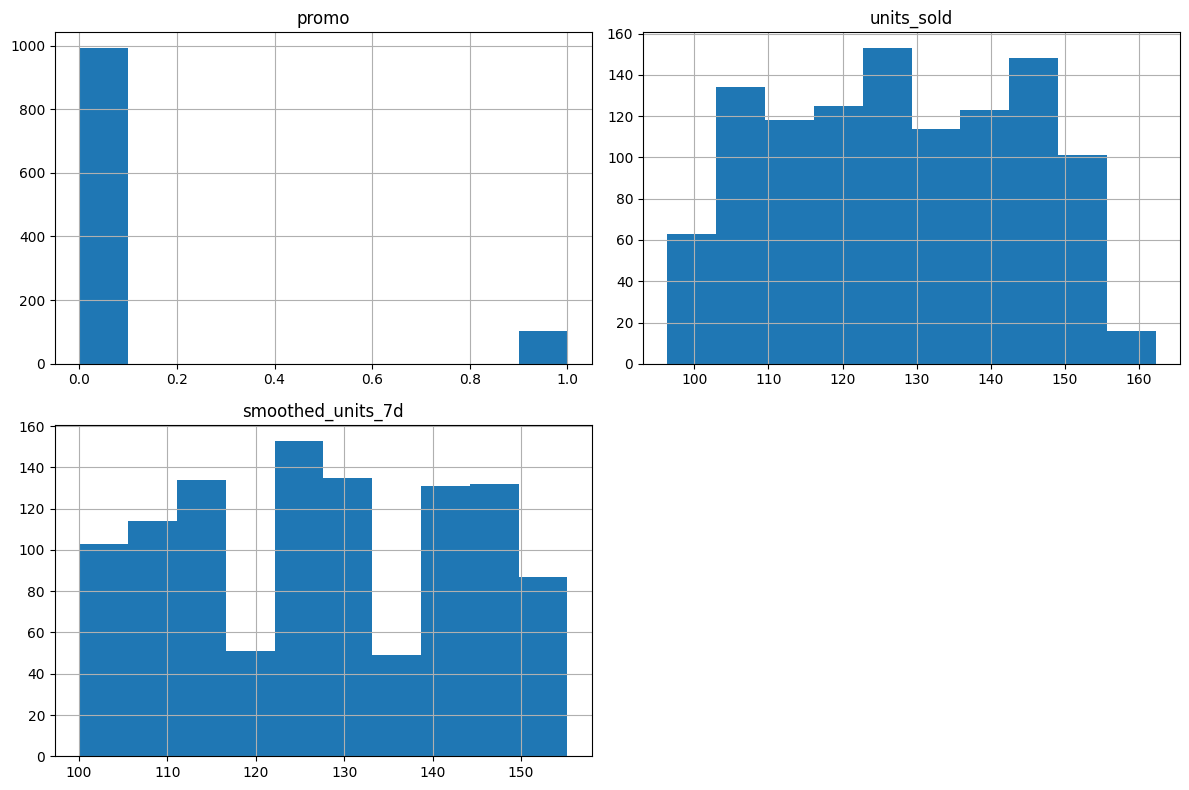

In [30]:
demand.select_dtypes(include=np.number).hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

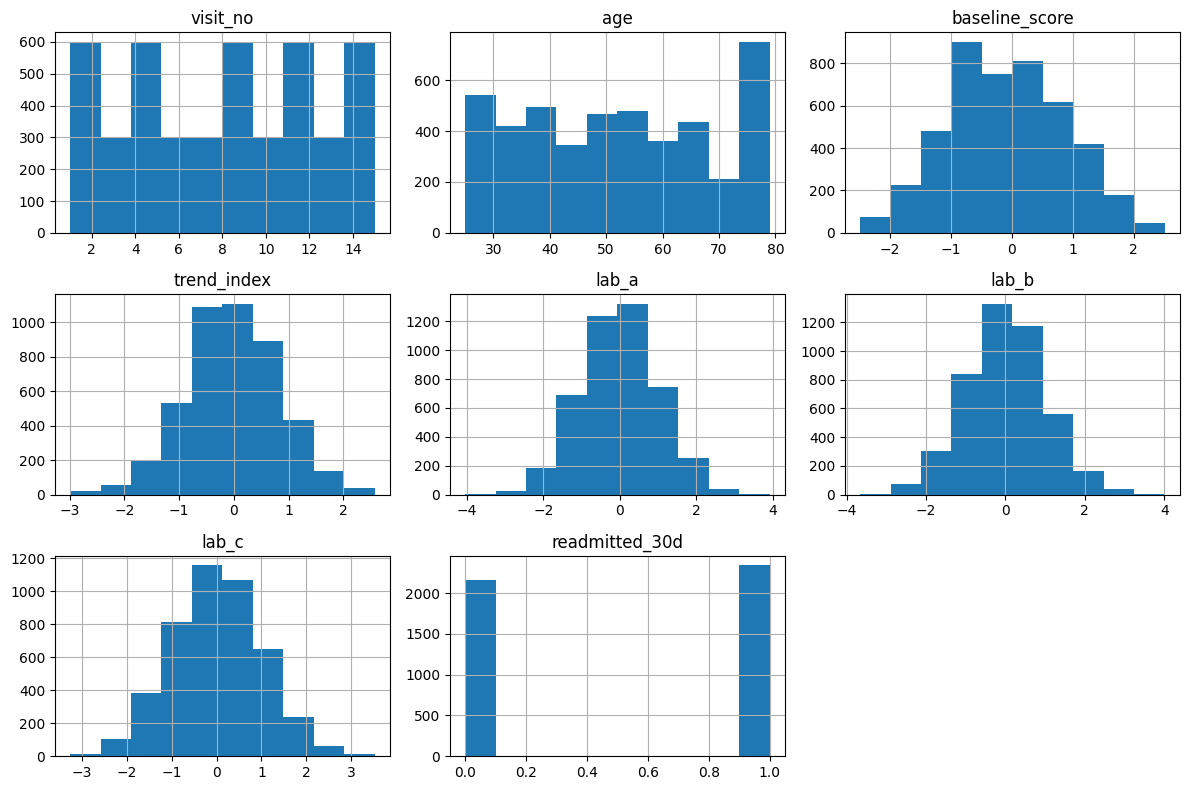

In [31]:
patients.select_dtypes(include=np.number).hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

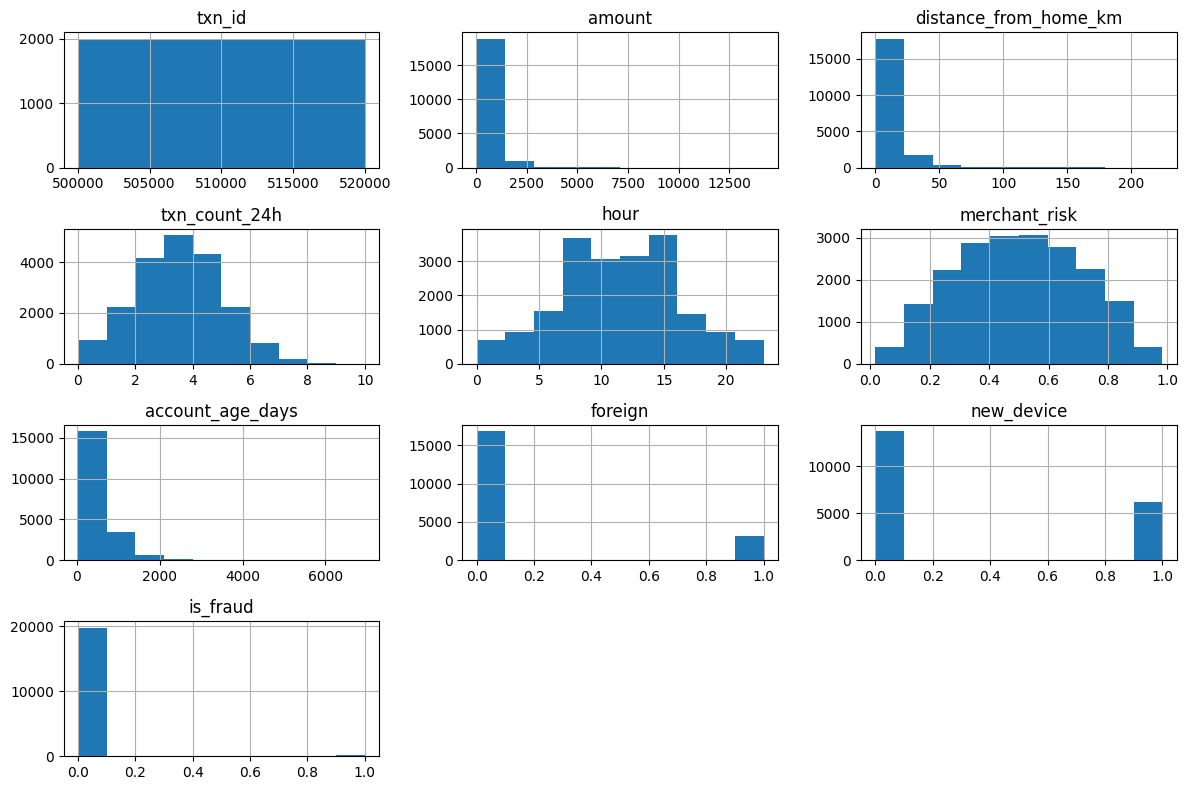

In [32]:
transactions.select_dtypes(include=np.number).hist(figsize=(12, 8))
plt.tight_layout()
plt.show()